# Tokenization

In [ ]:
model_names = ["bert-base-uncased",
               "roberta-base",
               "distilbert-base-uncased",
               "google/electra-base-discriminator"]
pretrained_model = model_names[0]

from transformers import AutoTokenizer
tokenizer = AutoTokenizer.from_pretrained(pretrained_model)
tokenized = tokenizer("Colored cats paint rats.", return_tensors="pt")

from transformers import AutoModel
model = AutoModel.from_pretrained(pretrained_model)
outputs = model(tokenized.input_ids, tokenized.attention_mask)
print("Input Tokens:", tokenizer.convert_ids_to_tokens(tokenized.input_ids[0]))
print("Model Output Shape:", outputs.last_hidden_state.shape)

Input Tokens: ['[CLS]', 'colored', 'cats', 'paint', 'rats', '.', '[SEP]']
Model Output Shape: torch.Size([1, 7, 768])


# Image Preprocessing

In [ ]:
model_names = ["google/vit-base-patch16-224",
               "microsoft/beit-base-patch16-224",
               "facebook/vit-mae-base"]
pretrained_model = model_names[0]

from transformers import AutoImageProcessor
from torchvision.datasets import OxfordIIITPet
processor = AutoImageProcessor.from_pretrained(pretrained_model, use_fast=True)
test_dataset = OxfordIIITPet(root='./data', split='test', download=True)
inputs = processor(images=test_dataset[0][0], return_tensors="pt")

from transformers import AutoModel
model = AutoModel.from_pretrained(pretrained_model)
outputs = model(**inputs)
print("Image Size:", test_dataset[0][0].size)
print("Input Image Shape:", inputs.pixel_values.shape)
print("Model Output Shape:", outputs.last_hidden_state.shape)

Some weights of ViTModel were not initialized from the model checkpoint at google/vit-base-patch16-224 and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Image Size: (300, 225)
Input Image Shape: torch.Size([1, 3, 224, 224])
Model Output Shape: torch.Size([1, 197, 768])


# Pre-Trained Models (Text)

Vocabulary size: 30522
Number of classes: 3
First example from the dataset:
Sentence: [CLS] conceptually cream skimming has two basic dimensions - product and geography. [SEP] product and geography are what make cream skimming work. [SEP]
Label: neutral
Layer (type:depth-idx)                                       Input Shape               Output Shape              Param #
TransformerEncoderClassifier                                 [32, 64]                  [32, 3]                   --
├─BertModel: 1-1                                             --                        [32, 768]                 --
│    └─BertEmbeddings: 2-1                                   --                        [32, 64, 768]             --
│    │    └─Embedding: 3-1                                   [32, 64]                  [32, 64, 768]             (23,440,896)
│    │    └─Embedding: 3-2                                   [32, 64]                  [32, 64, 768]             (1,536)
│    │    └─Embedding: 3-3    

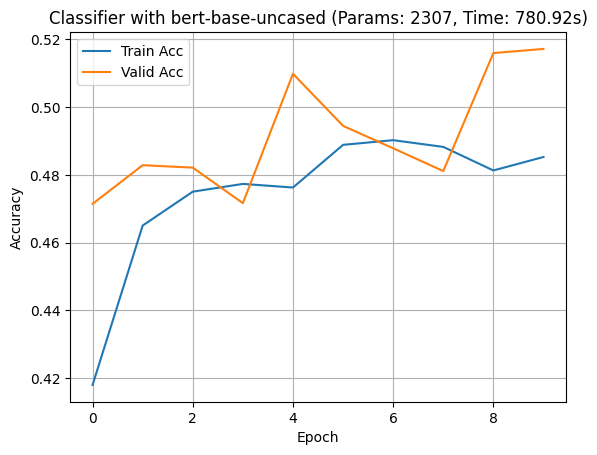

Test Accuracy: 0.520
              precision    recall  f1-score   support

           0       0.49      0.72      0.58      3463
           1       0.52      0.38      0.44      3129
           2       0.58      0.44      0.50      3240

    accuracy                           0.52      9832
   macro avg       0.53      0.51      0.51      9832
weighted avg       0.53      0.52      0.51      9832



In [ ]:
model_names = ["bert-base-uncased",
               "distilbert-base-uncased",
               "google/electra-base-discriminator"]
pretrained_model = model_names[0]

# (1) Data Loading
# Tokenizer
from transformers import AutoTokenizer
tokenizer = AutoTokenizer.from_pretrained(pretrained_model)
vocab_size = tokenizer.vocab_size
print(f"Vocabulary size: {vocab_size}")

# Dataset
from torch.utils.data import RandomSampler
# MultiNLI Dataset
from datasets import load_dataset
dataset = load_dataset("multi_nli")
num_classes = len(dataset["train"].features["label"].names)
print(f"Number of classes: {num_classes}")
def tokenize(batch):
    return tokenizer(batch["premise"], batch["hypothesis"], truncation=True, padding=False)
tokenized = dataset.map(tokenize, batched=True)
tokenized.set_format(type="torch", columns=["input_ids", "attention_mask", "label"])
train_set = tokenized["train"]
val_set = tokenized["validation_matched"]
test_set = tokenized["validation_mismatched"]
subset_size = len(train_set) // 30   # 1/30 of the training set is used
train_sampler = RandomSampler(train_set, num_samples=subset_size)

# Print the first example
print("First example from the dataset:")
print("Sentence:", tokenizer.decode(train_set[0]["input_ids"]))
print("Label:", dataset["train"].features["label"].names[train_set[0]["label"]])

# (2) DataLoader with padding
import torch
from torch.nn.utils.rnn import pad_sequence
from torch.utils.data import DataLoader

def collate_fn(batch):
    input_ids = pad_sequence([x["input_ids"] for x in batch], batch_first=True, padding_value=tokenizer.pad_token_id)
    attn_mask = pad_sequence([x["attention_mask"] for x in batch], batch_first=True, padding_value=0)
    labels = torch.tensor([x["label"] for x in batch])
    return input_ids, attn_mask, labels

train_loader = DataLoader(train_set, batch_size=32, sampler=train_sampler, collate_fn=collate_fn)
val_loader = DataLoader(val_set, batch_size=32, shuffle=False, collate_fn=collate_fn)
test_loader = DataLoader(test_set, batch_size=64, shuffle=False, collate_fn=collate_fn)

# (3) Model Definition
import torch.nn as nn
from transformers import AutoModel

# Transformer Encoder Classifier
class TransformerEncoderClassifier(nn.Module):
    def __init__(self, pretrained_model, num_classes, freeze_encoder=True):
        super(TransformerEncoderClassifier, self).__init__()
        self.encoder = AutoModel.from_pretrained(pretrained_model)
        # Freeze pre-trained model parameters
        if freeze_encoder:
            for param in self.encoder.parameters():
                param.requires_grad = False
        self.classifier = nn.Linear(self.encoder.config.hidden_size, num_classes)

    def forward(self, x, mask):
        outputs = self.encoder(input_ids=x, attention_mask=mask) # [batch_size, seq_len, hidden_size]
        cls_output = outputs.last_hidden_state[:, 0, :]  # [CLS] token vector, [batch_size, hidden_size]
        logits = self.classifier(cls_output)  # [batch_size, num_classes]
        return logits


# (4) Training function
import torch.optim as optim

def train(train_loader, val_loader, model, device):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    train_accs, val_accs = [], []

    best_acc = 0.0
    best_state = None

    for epoch in range(10):
        model.train()
        total_loss, correct, total = 0.0, 0, 0
        for x, mask, y in train_loader:
            x, mask, y = x.to(device), mask.to(device), y.to(device)
            optimizer.zero_grad()
            out = model(x, mask)
            loss = criterion(out, y)
            loss.backward()
            optimizer.step()
            total_loss += loss.item() * x.size(0)
            correct += (out.argmax(1) == y).sum().item()
            total += y.size(0)
        train_accs.append(correct / total)

        model.eval()
        total_loss, correct, total = 0.0, 0, 0
        with torch.no_grad():
            for x, mask, y in val_loader:
                x, mask, y = x.to(device), mask.to(device), y.to(device)
                out = model(x, mask)
                loss = criterion(out, y)
                total_loss += loss.item() * x.size(0)
                correct += (out.argmax(1) == y).sum().item()
                total += y.size(0)
        val_acc = correct / total
        if val_acc > best_acc:
            best_acc = val_acc
            best_state = model.state_dict()
        val_accs.append(correct / total)

        print(f"Epoch {epoch+1}: Train Acc = {train_accs[-1]:.3f}, Val Acc = {val_accs[-1]:.3f}")
    return train_accs, val_accs, best_state

# (5) Run training and plot the train/validation accuracy
import matplotlib.pyplot as plt
import torchinfo
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = TransformerEncoderClassifier(pretrained_model, num_classes).to(device)

print(torchinfo.summary(
    model,
    input_data=(torch.randint(0, vocab_size, (32, 64), device=device), 
                torch.ones(32, 64, dtype=torch.int64, device=device)),
    col_names=["input_size", "output_size", "num_params"]
))

# Measure the training time
import time
start_time = time.time()
print("Starting training...")
train_accs, test_accs, best_state = train(train_loader, val_loader, model, device)
end_time = time.time()
execution_time = end_time - start_time
print(f"Training time: {execution_time:.2f} seconds")
num_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
plt.plot(train_accs, label='Train Acc')
plt.plot(test_accs, label='Valid Acc')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title(f"Classifier with {pretrained_model} (Params: {num_params}, Time: {execution_time:.2f}s)")
plt.legend()
plt.grid(True)
plt.show()

# (6) Evaluate on test set
model.load_state_dict(best_state)
model.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for x, mask, y in test_loader:
        x, mask, y = x.to(device), mask.to(device), y.to(device)
        out = model(x, mask)
        all_preds.append(out.argmax(1).cpu())
        all_labels.append(y.cpu())
all_preds = torch.cat(all_preds)
all_labels = torch.cat(all_labels)
print(f"Test Accuracy: {torch.sum(all_preds == all_labels).item() / len(all_labels):.3f}")

from sklearn.metrics import classification_report
print(classification_report(all_labels.numpy(), all_preds.numpy()))

# Vision Transformer (ViT) Model

Sample shape: torch.Size([3, 224, 224]), Label: Abyssinian


Some weights of ViTModel were not initialized from the model checkpoint at google/vit-base-patch16-224 and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Layer (type (var_name))                                                Input Shape               Output Shape              Param #
ViTClassifier (ViTClassifier)                                          [32, 3, 224, 224]         [32, 37]                  --
├─ViTModel (vit)                                                       --                        [32, 768]                 --
│    └─ViTEmbeddings (embeddings)                                      [32, 3, 224, 224]         [32, 197, 768]            152,064
│    │    └─ViTPatchEmbeddings (patch_embeddings)                      [32, 3, 224, 224]         [32, 196, 768]            (590,592)
│    │    └─Dropout (dropout)                                          [32, 197, 768]            [32, 197, 768]            --
│    └─ViTEncoder (encoder)                                            [32, 197, 768]            [32, 197, 768]            --
│    │    └─ModuleList (layer)                                         --                        --  

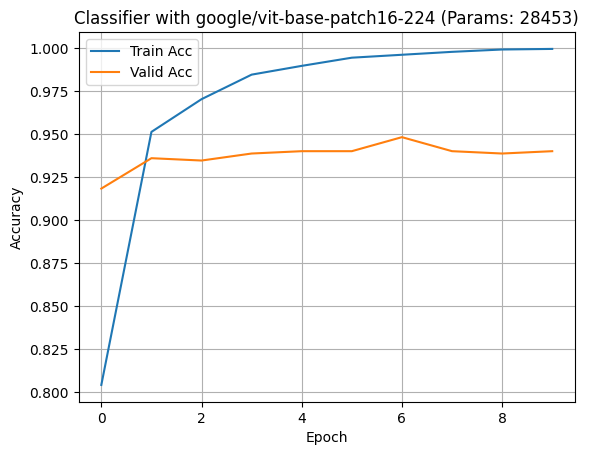

Test Accuracy: 0.926
              precision    recall  f1-score   support

           0       0.92      0.95      0.93        98
           1       0.81      0.87      0.84       100
           2       0.80      0.69      0.74       100
           3       0.98      0.94      0.96       100
           4       0.93      0.96      0.95       100
           5       0.80      0.89      0.84       100
           6       0.76      0.78      0.77       100
           7       0.87      0.99      0.93        88
           8       0.86      0.93      0.89        99
           9       0.90      0.80      0.85       100
          10       0.94      0.93      0.93       100
          11       0.93      0.86      0.89        97
          12       0.97      1.00      0.99       100
          13       0.99      0.97      0.98       100
          14       0.95      0.99      0.97       100
          15       1.00      0.97      0.98       100
          16       0.97      1.00      0.99       100
      

In [3]:
model_names = ["google/vit-base-patch16-224",
               "microsoft/beit-base-patch16-224",
               "facebook/vit-mae-base"]
pretrained_model = model_names[0]

# (1) Data Loading and Preprocessing
from transformers import AutoImageProcessor
processor = AutoImageProcessor.from_pretrained(pretrained_model, use_fast=True)
image_size = processor.size["height"]

import torch
from torchvision import transforms
from torch.utils.data import DataLoader

transform = transforms.Compose([
    transforms.Resize((image_size, image_size)),
    transforms.ToTensor()
])

# Oxford-IIIT Pets Dataset
from torchvision.datasets import OxfordIIITPet
trainval_dataset = OxfordIIITPet(root='./data', split='trainval', transform=transform, download=True)
test_dataset = OxfordIIITPet(root='./data', split='test', transform=transform, download=True)
num_classes = len(trainval_dataset.classes)

# Split trainval into train and validation sets
train_size = int(0.8 * len(trainval_dataset))
val_size = len(trainval_dataset) - train_size
train_dataset, val_dataset = torch.utils.data.random_split(trainval_dataset, [train_size, val_size])

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32)
test_loader = DataLoader(test_dataset, batch_size=64)

# Print the first sample
x, y = trainval_dataset[0]
print(f"Sample shape: {x.shape}, Label: {trainval_dataset.classes[y]}")

# (2) Training function
import torch.optim as optim

def train(train_loader, val_loader, model, optimizer, device):
    criterion = nn.CrossEntropyLoss()
    train_accs, val_accs = [], []

    best_acc = 0.0
    best_state = None

    for epoch in range(10):
        model.train()
        total_loss, correct, total = 0.0, 0, 0
        for x, y in train_loader:
            inputs = processor(images=list(x), return_tensors="pt", do_rescale=False)
            x, y = inputs['pixel_values'].to(device), y.to(device)
            optimizer.zero_grad()
            out = model(x)
            loss = criterion(out, y)
            loss.backward()
            optimizer.step()
            total_loss += loss.item() * x.size(0)
            correct += (out.argmax(1) == y).sum().item()
            total += y.size(0)
        train_accs.append(correct / total)

        model.eval()
        total_loss, correct, total = 0.0, 0, 0
        with torch.no_grad():
            for x, y in val_loader:
                inputs = processor(images=list(x), return_tensors="pt", do_rescale=False)
                x, y = inputs['pixel_values'].to(device), y.to(device)
                out = model(x)
                loss = criterion(out, y)
                total_loss += loss.item() * x.size(0)
                correct += (out.argmax(1) == y).sum().item()
                total += y.size(0)
        val_acc = correct / total
        if val_acc > best_acc:
            best_acc = val_acc
            best_state = model.state_dict()
        val_accs.append(correct / total)

        print(f"Epoch {epoch+1}: Train Acc = {train_accs[-1]:.3f}, Val Acc = {val_accs[-1]:.3f}")
    return train_accs, val_accs, best_state

# (3) Definition of the model and optimizer
from torch import nn
from transformers import AutoModel
import torchinfo

class ViTClassifier(nn.Module):
    def __init__(self, pretrained_model, num_classes, freeze_encoder=True):
        super().__init__()
        self.vit = AutoModel.from_pretrained(pretrained_model)
        if freeze_encoder:
            for param in self.vit.parameters():
                param.requires_grad = False
        self.classifier = nn.Linear(self.vit.config.hidden_size, num_classes)

    def forward(self, pixel_values):
        outputs = self.vit(pixel_values=pixel_values)
        cls_token = outputs.last_hidden_state[:, 0, :]  # [CLS]
        logits = self.classifier(cls_token)
        return logits

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = ViTClassifier(pretrained_model, num_classes, freeze_encoder=True).to(device)
print(torchinfo.summary(model, input_size=(32, 3, 224, 224), row_settings=["var_names"],
                        col_names=["input_size", "output_size", "num_params"]))
optimizer = optim.Adam(model.parameters(), lr=0.001)

# (4) Run training and plot the train/validation accuracy
import matplotlib.pyplot as plt
train_accs, test_accs, best_state = train(train_loader, val_loader, model, optimizer, device)
num_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
plt.plot(train_accs, label='Train Acc')
plt.plot(test_accs, label='Valid Acc')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title(f"Classifier with {pretrained_model} (Params: {num_params})")
plt.legend()
plt.grid(True)
plt.show()

# (5) Evaluate on test set
model.load_state_dict(best_state)
model.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for x, y in test_loader:
        inputs = processor(images=list(x), return_tensors="pt", do_rescale=False)
        x, y = inputs['pixel_values'].to(device), y.to(device)
        out = model(x)
        all_preds.append(out.argmax(1).cpu())
        all_labels.append(y.cpu())
all_preds = torch.cat(all_preds)
all_labels = torch.cat(all_labels)
print(f"Test Accuracy: {torch.sum(all_preds == all_labels).item() / len(all_labels):.3f}")

from sklearn.metrics import classification_report
print(classification_report(all_labels.numpy(), all_preds.numpy()))

#